# PayStone Customer Retention Intelligence Platform: AI-Based Churn Prediction and Explainable Analytics

# Import Required Libraries

In [19]:
# Import data manipulation libraries
import pandas as pd  # For data manipulation and analysis
import numpy as np   # For numerical operations

# Import data visualization libraries
import matplotlib.pyplot as plt  # For creating static visualizations
import seaborn as sns           # For enhanced statistical visualizations
import missingno as msno        # For visualisation of Missing Values
import os


# LabelEncoder:
# Converts binary categorical variables into numerical values.

from sklearn.preprocessing import LabelEncoder


# OrdinalEncoder:
# Converts ordered categorical variables while preserving ranking.

from sklearn.preprocessing import OrdinalEncoder


# OneHotEncoder:
# Converts nominal categorical variables into binary indicator columns.

from sklearn.preprocessing import OneHotEncoder


# SimpleImputer:
# Handles missing values before encoding.

from sklearn.impute import SimpleImputer


# Pipeline:
# Allows multiple preprocessing steps to be combined.

from sklearn.pipeline import Pipeline


# ColumnTransformer:
# Applies different preprocessing methods to different columns.

from sklearn.compose import ColumnTransformer



# Data Import and Inspections

In [20]:
# =============================================================================
# AUTOMATED DATA LOADING AND INITIAL DATA INSPECTION PIPELINE
# =============================================================================
#
# Objective:
# This pipeline automates the process of locating, importing, and inspecting
# a raw customer dataset before data cleaning and preprocessing.
#
# The workflow ensures:
# - Reproducible data loading
# - Reduced dependency on manual file paths
# - Early identification of data quality issues
# - Understanding of dataset structure before modelling
#
# This represents the first stage of the machine learning lifecycle:
#
# Raw Data 
#    ↓
# Data Loading
#    ↓
# Data Understanding
#    ↓
# Data Cleaning & Preprocessing
#    ↓
# Feature Engineering
#    ↓
# Model Development
#
# =============================================================================


def load_and_inspect_dataset(file_path=None):

    """
    Automated Data Loading and Initial Data Inspection Function
    
    Parameters:
    -----------
    file_path : str, optional
        Location of the CSV dataset. If no path is supplied, the function
        automatically searches the current working directory for a CSV file.
    
    Returns:
    --------
    df : pandas.DataFrame
        Imported customer dataset ready for further preprocessing.
    
    Pipeline Activities:
    --------------------
    1. Locate dataset automatically
    2. Import raw customer data
    3. Validate successful loading
    4. Preview sample records
    5. Examine dataset structure
    6. Identify available features
    7. Confirm dataset size
    """


    # =========================================================================
    # STEP 1: AUTOMATIC DATASET DISCOVERY
    # =========================================================================
    #
    # Purpose:
    # Automatically identify the input dataset without manually specifying
    # the file name. This improves portability when moving the project between:
    #
    # - Local development environment
    # - Jupyter Notebook
    # - GitHub repository
    # - Cloud deployment platforms
    #
    # If a file path is provided by the user, this step is skipped.
    #
    if file_path is None:

        # Search the current working directory and return all files
        # ending with ".csv".
        csv_files = [
            file for file in os.listdir()
            if file.lower().endswith(".csv")
        ]


        # Validate that at least one CSV dataset exists.
        # Without this check, the import process would fail with a
        # less informative error message.
        if len(csv_files) == 0:
            raise FileNotFoundError(
                "No CSV dataset found in the current working directory."
            )


        # Automatically select the first CSV file identified.
        # This removes the need to manually update file names.
        file_path = csv_files[0]

# =========================================================================
    # STEP 2: DATA IMPORT
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Load the identified CSV file into a pandas DataFrame.
    #
    # A pandas DataFrame provides a structured tabular format that supports:
    #
    # - Data cleaning
    # - Exploratory data analysis
    # - Feature engineering
    # - Machine learning modelling
    #
    # The imported dataframe will become the main data object used throughout
    # the customer churn prediction pipeline.
    #
    # =========================================================================


    df = pd.read_csv(file_path)


    print("=" * 75)
    print(f"Dataset Successfully Imported: {file_path}")
    print("=" * 75)
    column_mapping = {
        "CLIENTNUM": "Customer_ID",
        "Attrition_Flag": "Churn",
        "Months_Inactive_12_mon": "Inactive_Months_Last_12_Months",
        "Contacts_Count_12_mon": "Contacts_Last_12_Months",
        "Total_Amt_Chng_Q4_Q1": "Transaction_Amount_Change_Q4_Q1",
        "Total_Trans_Ct": "Total_Transaction_Count",
        "Total_Ct_Chng_Q4_Q1": "Transaction_Count_Change_Q4_Q1"
    }

    # Apply column name changes
    df.rename(columns=column_mapping, inplace=True)
       
    # =========================================================================
    # STEP 3: STANDARDISE COLUMN NAMES
    # =========================================================================
    #
    # Purpose:
    # Rename selected columns to improve readability and maintain a
    # consistent naming convention throughout the machine learning pipeline.
    #
    # Identifier columns are renamed for clarity, while abbreviated feature
    # names are expanded to improve interpretability.
    #
    
    # =========================================================================
    # STEP 4: INITIAL DATA PREVIEW
    # =========================================================================
    #
    # Purpose:
    # Inspect sample records to understand:
    #
    # - Dataset layout
    # - Feature naming conventions
    # - Data formatting
    # - Customer-level observations
    #
    # The first five rows provide a quick validation that the dataset
    # has been imported correctly.
    #
    print("\nFirst 5 Rows of Dataset:")
    display(df.head())



    # Display the final five records.
    #
    # Purpose:
    # Confirm that the complete dataset has been loaded and check whether
    # there are any irregularities at the end of the file.
    #
    print("\nLast 5 Rows of Dataset:")
    display(df.tail())



    # =========================================================================
    # STEP 5: DATASET STRUCTURE AND QUALITY ASSESSMENT
    # =========================================================================
    #
    # Purpose:
    # Generate a technical summary of the dataset.
    #
    # The df.info() output provides:
    #
    # - Number of observations
    # - Feature names
    # - Data types
    # - Non-null value counts
    # - Memory utilisation
    #
    # This identifies potential preprocessing tasks:
    #
    # - Missing value handling
    # - Categorical variable encoding
    # - Numerical transformation
    # - Data type correction
    #
    print("\nDataset Information:")
    df.info()



    # =========================================================================
    # STEP 6: FEATURE / COLUMN IDENTIFICATION
    # =========================================================================
    #
    # Purpose:
    # Display all variables available in the dataset.
    #
    # This supports:
    #
    # - Understanding customer attributes
    # - Identifying target variable
    # - Detecting identifier fields
    # - Planning feature selection
    #
    # Example:
    # Attrition_Flag → Target variable for churn prediction
    # CLIENTNUM      → Customer identifier (potential removal)
    #
    print("\nDataset Column Names:")
    print(df.columns.tolist())



    # =========================================================================
    # STEP 7: DATASET DIMENSION CHECK
    # =========================================================================
    #
    # Purpose:
    # Confirm the size of the dataset.
    #
    # Output:
    # (Rows, Columns)
    #
    # Rows:
    #   Number of customer observations
    #
    # Columns:
    #   Number of available features
    #
    # This provides a baseline before:
    # - Data cleaning
    # - Feature engineering
    # - Model development
    #
    print("\nDataset Shape (Rows, Columns):")
    print(df.shape)



    # =========================================================================
    # STEP 8: RETURN PROCESSED DATA OBJECT
    # =========================================================================
    #
    # Return the imported DataFrame so that subsequent machine learning
    # pipeline stages can continue using the same dataset object.
    #
    # Next stages:
    # - Data Cleaning
    # - Exploratory Data Analysis
    # - Feature Engineering
    # - Model Training
    #
    return df



# =============================================================================
# EXECUTE AUTOMATED DATA IMPORT PIPELINE
# =============================================================================
#
# The function call performs:
# Dataset discovery → Import → Inspection → Validation
#
# The resulting dataframe will be used in the next stage:
# "Data Cleaning and Preprocessing"
#
# =============================================================================

df = load_and_inspect_dataset()



Dataset Successfully Imported: churn_clean.csv

First 5 Rows of Dataset:


,Churn,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Inactive_Months_Last_12_Months,Contacts_Last_12_Months,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Transaction_Amount_Change_Q4_Q1,Total_Trans_Amt,Total_Transaction_Count,Transaction_Count_Change_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000



Last 5 Rows of Dataset:


,Churn,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Inactive_Months_Last_12_Months,Contacts_Last_12_Months,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Transaction_Amount_Change_Q4_Q1,Total_Trans_Amt,Total_Transaction_Count,Transaction_Count_Change_Q4_Q1,Avg_Utilization_Ratio
10122,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000
10126,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,6,2,4,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Churn                            10127 non-null  object 
 1   Customer_Age                     10127 non-null  int64  
 2   Gender                           10127 non-null  object 
 3   Dependent_count                  10127 non-null  int64  
 4   Education_Level                  10127 non-null  object 
 5   Marital_Status                   10127 non-null  object 
 6   Income_Category                  10127 non-null  object 
 7   Card_Category                    10127 non-null  object 
 8   Months_on_book                   10127 non-null  int64  
 9   Total_Relationship_Count         10127 non-null  int64  
 10  Inactive_Months_Last_12_Months   10127 non-null  int64  
 11  Contacts_Last_12_Months          10127 non-null  int64  
 

# Investigating Descripancies in Categorical Variables 

In [21]:
# =============================================================================
# AUTOMATED CATEGORICAL VARIABLE UNIQUENESS ANALYSIS PIPELINE
# =============================================================================
#
# Objective:
# This pipeline automatically identifies categorical variables within the
# customer dataset and analyses the number of unique categories contained
# within each variable.
#
# Understanding categorical variables is a critical preprocessing step because
# machine learning algorithms cannot directly process text-based categories.
#
# The analysis helps determine:
#
# - Which variables require encoding
# - The appropriate encoding technique
# - Whether variables contain high cardinality
# - Whether unexpected categories exist
# - Whether missing/unknown categories require treatment
#
# Workflow:
#
# Raw Dataset
#      ↓
# Identify Categorical Features
#      ↓
# Calculate Unique Categories
#      ↓
# Review Category Distribution
#      ↓
# Select Encoding Strategy
#      ↓
# Prepare Data for Machine Learning
#
# =============================================================================


def analyse_categorical_variables(df):

    """
    Automated function to identify categorical variables and analyse
    their unique categories.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input customer dataset containing numerical and categorical features.
        
    Returns:
    --------
    categorical_summary : pandas.DataFrame
        Summary table containing:
        - Categorical feature names
        - Number of unique categories
        - Available category values
    """


    # =========================================================================
    # STEP 1: IDENTIFY CATEGORICAL VARIABLES
    # =========================================================================
    #
    # Purpose:
    # Automatically detect columns containing categorical/text information.
    #
    # Machine learning models require numerical input, therefore categorical
    # variables must be identified before applying encoding techniques.
    #
    # Examples from customer churn datasets:
    #
    # Gender            → M / F
    # Education_Level   → Graduate / High School / Unknown
    # Income_Category   → Income bands
    # Card_Category     → Card types
    #
    # select_dtypes() filters the dataframe based on column data type.
    # "object" columns typically represent text-based categorical variables.
    #
    categorical_columns = df.select_dtypes(
        include=["object"]
    ).columns



    # =========================================================================
    # STEP 2: CALCULATE CATEGORY UNIQUENESS
    # =========================================================================
    #
    # Purpose:
    # Determine the number of distinct categories available within each
    # categorical variable.
    #
    # This information is important because:
    #
    # Low cardinality variables:
    #   - Small number of categories
    #   - Suitable for One-Hot Encoding
    #
    # High cardinality variables:
    #   - Large number of categories
    #   - May require alternative encoding methods
    #
    # Example:
    #
    # Gender:
    #   Unique_Count = 2
    #
    # Education_Level:
    #   Unique_Count = 7
    #
    categorical_summary = pd.DataFrame({

        # Store categorical feature names
        "Feature": categorical_columns,


        # Count the number of unique categories in each feature
        "Unique_Count": [
            df[column].nunique()
            for column in categorical_columns
        ],


        # Display the actual category values available
        # Useful for identifying:
        # - Unexpected values
        # - Missing categories
        # - Data quality issues
        "Unique_Values": [
            df[column].unique().tolist()
            for column in categorical_columns
        ]
    })



    # =========================================================================
    # STEP 3: DISPLAY CATEGORICAL ANALYSIS RESULTS
    # =========================================================================
    #
    # Purpose:
    # Provide a clear summary of categorical variables before preprocessing.
    #
    # This output supports decisions regarding:
    #
    # - Label Encoding
    # - One-Hot Encoding
    # - Category grouping
    # - Missing value treatment
    #
    print("=" * 75)
    print("Categorical Variable Uniqueness Analysis")
    print("=" * 75)

    display(categorical_summary)



    # =========================================================================
    # STEP 4: RETURN ANALYSIS RESULTS
    # =========================================================================
    #
    # Purpose:
    # Return the summary dataframe so it can be reused in later stages:
    #
    # - Feature engineering
    # - Encoding pipeline
    # - Exploratory data analysis
    # - Model preparation
    #
    return categorical_summary



# =============================================================================
# EXECUTE CATEGORICAL VARIABLE ANALYSIS PIPELINE
# =============================================================================
#
# Run automated categorical feature analysis on the customer dataset.
#
# Output:
# categorical_summary contains a complete overview of categorical variables
# and their unique values.
#
# =============================================================================

categorical_summary = analyse_categorical_variables(df)

Categorical Variable Uniqueness Analysis


,Feature,Unique_Count,Unique_Values
0,Churn,2,"[Existing Customer, Attrited Customer]"
1,Gender,2,"[M, F]"
2,Education_Level,7,"[High School, Graduate, Uneducated, Unknown, C..."
3,Marital_Status,4,"[Married, Single, Unknown, Divorced]"
4,Income_Category,6,"[$60K - $80K, Less than $40K, $80K - $120K, $4..."
5,Card_Category,4,"[Blue, Gold, Silver, Platinum]"


# Remove Unwanted Columns 

In [22]:
# =============================================================================
# AUTOMATED IDENTIFIER COLUMN REMOVAL PIPELINE
# =============================================================================
#
# Objective:
# Remove non-predictive identifier columns from the dataset before
# exploratory data analysis and machine learning model development.
#
# Identifier variables uniquely distinguish each customer but do not
# contain behavioural or transactional information useful for predicting
# customer churn.
#
# Retaining unique identifiers during model training may:
#
# • Introduce unnecessary information
# • Increase computational complexity
# • Reduce model generalisation
# • Increase the risk of overfitting
#
# Workflow:
#
# Customer Dataset
#        ↓
# Identify Identifier Columns
#        ↓
# Validate Column Existence
#        ↓
# Remove Identifier Columns
#        ↓
# Return Clean Dataset
#
# =============================================================================


def drop_identifier_columns(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Removes non-predictive identifier columns from the dataset.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input customer dataset.

    Returns
    -------
    pandas.DataFrame
        Cleaned dataframe with identifier columns removed.
    """


    # =========================================================================
    # STEP 1: DEFINE IDENTIFIER COLUMNS
    # =========================================================================
    #
    # Purpose:
    # Specify columns that uniquely identify each customer.
    #
    # These variables are excluded because they contain no predictive
    # information regarding customer behaviour or churn.
    #
    # Example:
    # Customer_ID → Unique customer reference number
    #
    columns_to_drop = [
        "Customer_ID"
    ]


    # =========================================================================
    # STEP 2: VERIFY COLUMN EXISTENCE
    # =========================================================================
    #
    # Purpose:
    # Check whether each specified identifier column exists in the dataset.
    #
    # This prevents errors if:
    #
    # • The column has already been removed
    # • The dataset structure changes
    # • Different datasets are used with the same pipeline
    #
    existing_columns = [
        column
        for column in columns_to_drop
        if column in dataframe.columns
    ]


    # =========================================================================
    # STEP 3: REMOVE IDENTIFIER COLUMNS
    # =========================================================================
    #
    # Purpose:
    # Remove all identifier columns that exist in the dataset.
    #
    # Dropping these variables ensures that only meaningful customer
    # characteristics are used during:
    #
    # • Exploratory Data Analysis
    # • Feature Engineering
    # • Machine Learning Model Training
    # • Explainable AI Analysis
    #
    if existing_columns:

        print("=" * 75)
        print("Identifier Column Removal")
        print("=" * 75)

        print(f"Columns Removed: {existing_columns}")

        dataframe = dataframe.drop(
            columns=existing_columns,
            axis=1
        )

    else:

        # Inform the user when no identifier columns are found.
        print("=" * 75)
        print("Identifier Column Removal")
        print("=" * 75)

        print("No identifier columns were found.")


    # =========================================================================
    # STEP 4: DISPLAY UPDATED DATASET STRUCTURE
    # =========================================================================
    #
    # Purpose:
    # Display the remaining variables after identifier removal.
    #
    # This provides confirmation that the dataset now contains only
    # candidate predictor variables and the target variable.
    #
    print("\nRemaining Columns:")
    print(dataframe.columns.tolist())



    # =========================================================================
    # STEP 5: RETURN CLEANED DATAFRAME
    # =========================================================================
    #
    # Purpose:
    # Return the cleaned dataframe so it can be passed directly to the
    # next stage of the machine learning pipeline.
    #
    # Next stages include:
    #
    # • Missing Value Analysis
    # • Duplicate Detection
    # • Outlier Detection
    # • Feature Engineering
    # • Feature Encoding
    # • Machine Learning Model Development
    #
    return dataframe


# =============================================================================
# EXECUTE IDENTIFIER COLUMN REMOVAL PIPELINE
# =============================================================================
#
# Execute the automated identifier removal process.
#
# The returned dataframe contains only variables relevant for customer
# churn analysis and predictive modelling.
#
# =============================================================================

df = drop_identifier_columns(df)

Identifier Column Removal
No identifier columns were found.

Remaining Columns:
['Churn', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Inactive_Months_Last_12_Months', 'Contacts_Last_12_Months', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Transaction_Amount_Change_Q4_Q1', 'Total_Trans_Amt', 'Total_Transaction_Count', 'Transaction_Count_Change_Q4_Q1', 'Avg_Utilization_Ratio']


# Investigating and Handling Missing Values

In [23]:
# =============================================================================
# AUTOMATED MISSING VALUE ANALYSIS PIPELINE
# =============================================================================
#
# Objective:
# Automatically detect, quantify, and summarise missing values within the
# customer dataset before data cleaning and machine learning model development.
#
# Missing values are one of the most common data quality issues encountered
# during data preprocessing. If left untreated, they can:
#
# • Reduce predictive model accuracy
# • Introduce bias into model predictions
# • Cause certain machine learning algorithms to fail
# • Distort statistical summaries and feature distributions
#
# This automated pipeline identifies missing values and calculates the
# percentage of missing data for every feature, allowing informed decisions
# regarding data cleaning strategies.
#
# Workflow:
#
# Raw Dataset
#       ↓
# Detect Missing Values
#       ↓
# Count Missing Values
#       ↓
# Calculate Missing Percentage
#       ↓
# Generate Missing Value Report
#       ↓
# Select Appropriate Imputation Strategy
#
# =============================================================================


def analyse_missing_values(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Performs an automated missing value assessment.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input customer dataset.

    Returns
    -------
    pandas.DataFrame
        Summary table containing:

        • Feature name
        • Number of missing values
        • Percentage of missing values
    """


    # =========================================================================
    # STEP 1: CALCULATE MISSING VALUE COUNT
    # =========================================================================
    #
    # Purpose:
    # Determine how many missing (NaN) observations exist within each feature.
    #
    # isnull():
    #     Identifies missing values.
    #
    # sum():
    #     Counts the total number of missing values per column.
    #
    # Example:
    #
    # Age
    # ----
    # NaN
    # 45
    # 50
    #
    # Missing count = 1
    #
    missing_count = dataframe.isnull().sum()



    # =========================================================================
    # STEP 2: CALCULATE MISSING VALUE PERCENTAGE
    # =========================================================================
    #
    # Purpose:
    # Calculate the proportion of missing observations relative to the total
    # number of records.
    #
    # Formula:
    #
    # Missing Percentage =
    #
    # (Missing Values / Total Records) × 100
    #
    # The percentage provides a better indication of data quality than the
    # raw count alone.
    #
    missing_percentage = (
        missing_count / len(dataframe) * 100
    ).round(2)



    # =========================================================================
    # STEP 3: CREATE MISSING VALUE SUMMARY TABLE
    # =========================================================================
    #
    # Purpose:
    # Combine the missing value statistics into a single structured table.
    #
    # The resulting summary includes:
    #
    # • Feature name
    # • Number of missing values
    # • Percentage of missing values
    #
    # This table serves as the primary data quality report for the dataset.
    #
    missing_summary = pd.DataFrame({

        "Feature": dataframe.columns,

        "Missing_Values": missing_count.values,

        "Missing_Percentage (%)": missing_percentage.values

    })



    # =========================================================================
    # STEP 4: FILTER FEATURES CONTAINING MISSING VALUES
    # =========================================================================
    #
    # Purpose:
    # Remove variables that contain no missing values.
    #
    # Displaying only affected variables produces a cleaner report and allows
    # analysts to focus on features requiring preprocessing.
    #
    # The table is sorted in descending order so that variables with the
    # greatest amount of missing data appear first.
    #
    missing_summary = (

        missing_summary

        .loc[missing_summary["Missing_Values"] > 0]

        .sort_values(
            by="Missing_Values",
            ascending=False
        )

        .reset_index(drop=True)

    )



    # =========================================================================
    # STEP 5: DISPLAY MISSING VALUE REPORT
    # =========================================================================
    #
    # Purpose:
    # Present an easy-to-read summary describing the overall completeness
    # of the dataset.
    #
    # Two possible outcomes:
    #
    # Scenario 1:
    # No missing values exist.
    #
    # Scenario 2:
    # One or more variables contain missing observations.
    #
    print("=" * 75)
    print("Missing Value Analysis Report")
    print("=" * 75)

    if missing_summary.empty:

        print("No missing values detected in the dataset.")

    else:

        print(f"Number of affected features: {len(missing_summary)}")

        print(
            f"Total missing values: "
            f"{missing_summary['Missing_Values'].sum()}"
        )

        display(missing_summary)



    # =========================================================================
    # STEP 6: RETURN ANALYSIS RESULTS
    # =========================================================================
    #
    # Purpose:
    # Return the summary dataframe for downstream preprocessing.
    #
    # The returned object can be used to determine appropriate data cleaning
    # techniques such as:
    #
    # • Mean Imputation
    # • Median Imputation
    # • Mode Imputation
    # • Forward/Backward Fill
    # • KNN Imputation
    # • Multiple Imputation
    # • Feature Removal
    #
    return missing_summary



# =============================================================================
# EXECUTE AUTOMATED MISSING VALUE ANALYSIS
# =============================================================================
#
# Run the missing value assessment on the customer dataset.
#
# Output:
#
# • Summary table of missing values
# • Missing value percentages
# • Overall dataset completeness
#
# The results will guide the next stage of the preprocessing pipeline:
#
# Missing Value Treatment
#        ↓
# Duplicate Detection
#        ↓
# Outlier Detection
#        ↓
# Feature Engineering
#        ↓
# Machine Learning Modelling
#
# =============================================================================

missing_summary = analyse_missing_values(df)

Missing Value Analysis Report
No missing values detected in the dataset.


Missing Value Visualisation
No missing values detected in the dataset.
Dataset Completeness: 100%
Generating visual confirmation...



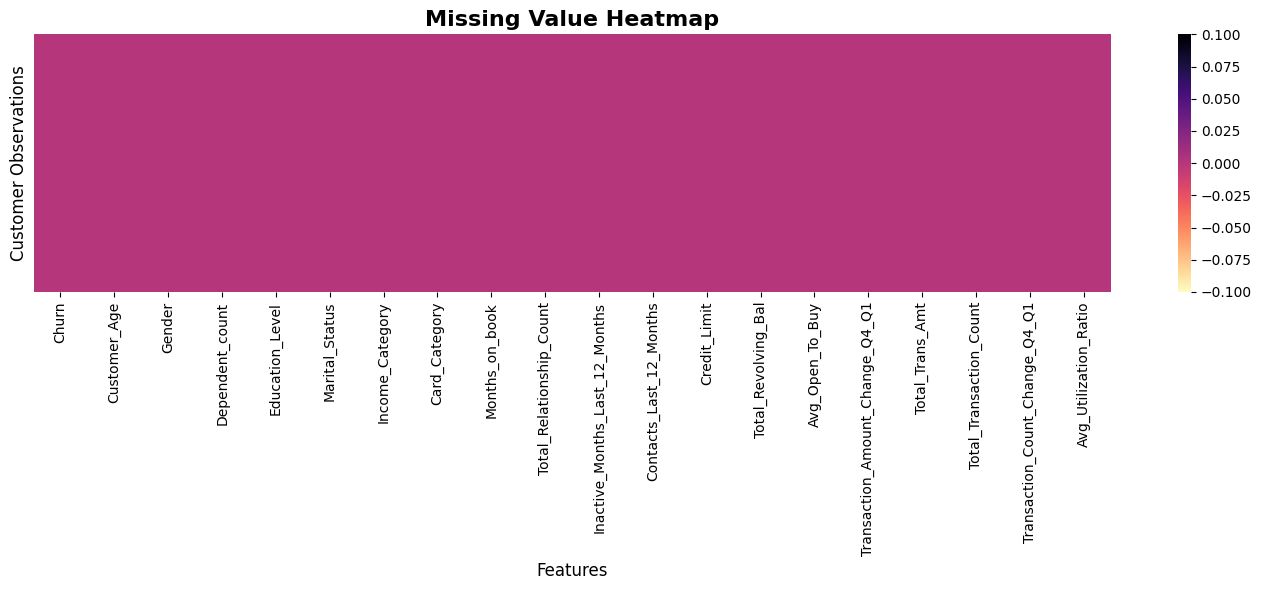

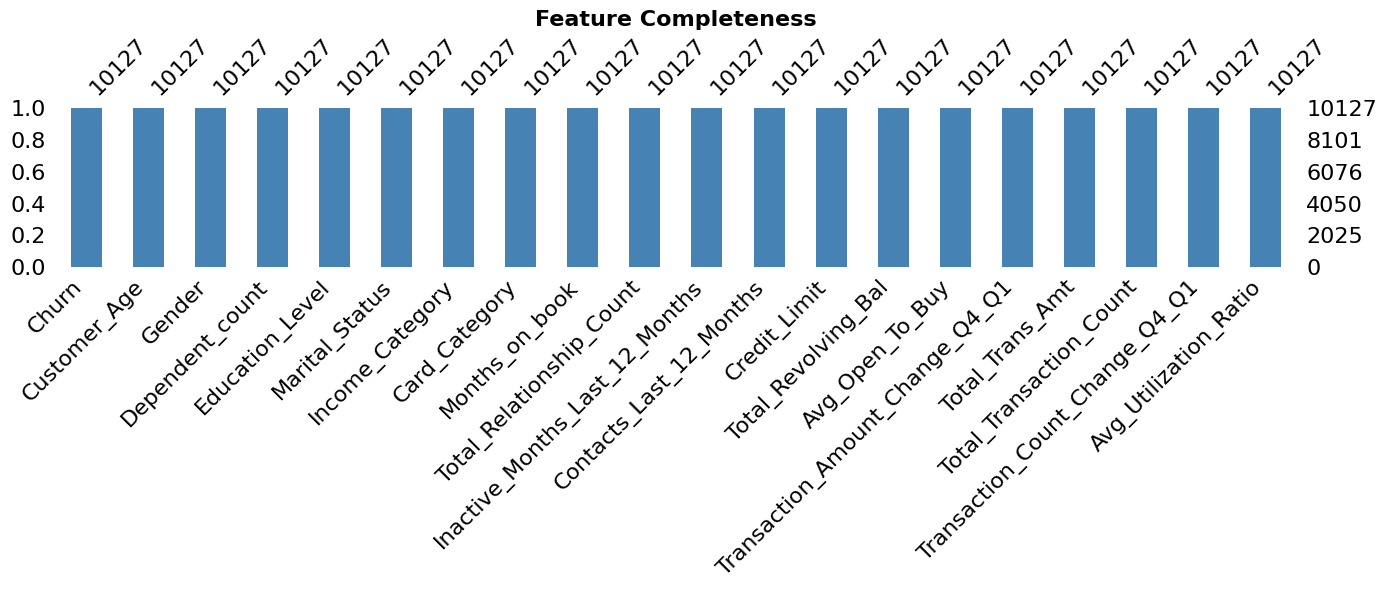

Missing Value Visualisation Completed Successfully
Total Features Analysed : 20
Total Records Analysed  : 10127
Total Missing Values    : 0
Overall Assessment      : Dataset is 100% Complete


In [24]:
# =============================================================================
# AUTOMATED MISSING VALUE VISUALISATION PIPELINE
# =============================================================================
#
# Objective:
# Automatically assess and visualise missing values within the customer
# dataset before data cleaning and machine learning model development.
#
# Missing value visualisation complements numerical missing value analysis by
# providing an intuitive graphical assessment of data completeness and
# identifying any patterns of missingness.
#
# This pipeline always generates the visualisations, even when no missing
# values exist, providing visual confirmation that the dataset is complete.
#
# Visualisations Produced:
#
# 1. Missing Value Heatmap (Seaborn)
#    • Displays the location of missing values
#    • Identifies systematic or random missingness
#
# 2. Feature Completeness Chart (Missingno)
#    • Displays the completeness of every feature
#    • Highlights variables requiring preprocessing
#
# Workflow:
#
# Customer Dataset
#         ↓
# Detect Missing Values
#         ↓
# Calculate Missing Values
#         ↓
# Report Dataset Completeness
#         ↓
# Generate Missing Value Heatmap
#         ↓
# Generate Feature Completeness Chart
#         ↓
# Confirm Data Quality
#
# =============================================================================


def visualise_missing_values(dataframe: pd.DataFrame):
    """
    Generates graphical visualisations of missing values within the dataset.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Customer dataset.

    Returns
    -------
    None

    Displays
    --------
    • Missing Value Heatmap
    • Feature Completeness Chart
    """


    # =========================================================================
    # STEP 1: CALCULATE TOTAL NUMBER OF MISSING VALUES
    # =========================================================================
    #
    # Purpose:
    # Determine the total number of missing observations within the dataset.
    #
    # isnull()
    #     Detects missing (NaN) values.
    #
    # sum().sum()
    #     Counts missing values across every feature.
    #
    total_missing = dataframe.isnull().sum().sum()



    # =========================================================================
    # STEP 2: REPORT DATASET COMPLETENESS
    # =========================================================================
    #
    # Purpose:
    # Inform the user whether missing values are present before generating
    # graphical visualisations.
    #
    print("=" * 75)
    print("Missing Value Visualisation")
    print("=" * 75)

    if total_missing == 0:

        print("No missing values detected in the dataset.")
        print("Dataset Completeness: 100%")
        print("Generating visual confirmation...\n")

    else:

        print(f"Total Missing Values Detected: {total_missing}")
        print("Generating missing value visualisations...\n")



    # =========================================================================
    # STEP 3: GENERATE MISSING VALUE HEATMAP
    # =========================================================================
    #
    # Purpose:
    # Display the location of missing values across the dataset.
    #
    # Interpretation:
    #
    # Rows:
    #     Customer observations.
    #
    # Columns:
    #     Dataset features.
    #
    # Colour:
    #     Indicates whether observations are present or missing.
    #
    # A uniform colour indicates a complete dataset.
    #
    plt.figure(figsize=(14, 6))

    sns.heatmap(
        dataframe.isnull(),
        cmap="magma_r",
        cbar=True,
        yticklabels=False
    )

    plt.title(
        "Missing Value Heatmap",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Features", fontsize=12)
    plt.ylabel("Customer Observations", fontsize=12)

    plt.tight_layout()

    plt.show()



    # =========================================================================
    # STEP 4: GENERATE FEATURE COMPLETENESS CHART
    # =========================================================================
    #
    # Purpose:
    # Display the completeness of every feature using the Missingno library.
    #
    # Interpretation:
    #
    # Taller bars:
    #     Complete variables.
    #
    # Shorter bars:
    #     Variables containing missing observations.
    #
    # This chart provides a quick assessment of overall dataset quality.
    #
    msno.bar(
        dataframe,
        figsize=(14, 6),
        color="steelblue"
    )

    plt.title(
        "Feature Completeness",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()



    # =========================================================================
    # STEP 5: SUMMARY
    # =========================================================================
    #
    # Purpose:
    # Provide a concise summary after generating the visualisations.
    #
    print("=" * 75)
    print("Missing Value Visualisation Completed Successfully")
    print("=" * 75)

    print(f"Total Features Analysed : {dataframe.shape[1]}")
    print(f"Total Records Analysed  : {dataframe.shape[0]}")
    print(f"Total Missing Values    : {total_missing}")

    if total_missing == 0:
        print("Overall Assessment      : Dataset is 100% Complete")
    else:
        print("Overall Assessment      : Missing values detected")



# =============================================================================
# EXECUTE AUTOMATED MISSING VALUE VISUALISATION PIPELINE
# =============================================================================
#
# Execute the automated missing value visualisation process.
#
# This stage complements the numerical missing value analysis by providing
# graphical evidence of dataset completeness before:
#
# • Missing Value Treatment
# • Duplicate Detection
# • Outlier Analysis
# • Feature Engineering
# • Machine Learning Model Development
#
# =============================================================================

visualise_missing_values(df)

# Handling Duplicated Variables

In [25]:
# =============================================================================
# AUTOMATED DUPLICATE RECORD DETECTION AND REMOVAL PIPELINE
# =============================================================================
#
# Objective:
# Automatically identify and remove duplicate customer records from the
# dataset before exploratory data analysis and machine learning.
#
# Duplicate records occur when two or more rows contain identical values
# across all features. These duplicate observations can negatively impact
# data quality and model performance by:
#
# • Biasing statistical summaries
# • Distorting feature distributions
# • Increasing the likelihood of overfitting
# • Inflating dataset size unnecessarily
#
# This pipeline detects duplicate observations, reports the findings,
# removes duplicates where necessary, and returns a cleaned dataset.
#
# Workflow:
#
# Customer Dataset
#         ↓
# Detect Duplicate Records
#         ↓
# Count Duplicate Records
#         ↓
# Remove Duplicate Records
#         ↓
# Reset Dataset Index
#         ↓
# Return Clean Dataset
#
# =============================================================================


def remove_duplicate_records(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Detects and removes duplicate records from the dataset.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input customer dataset.

    Returns
    -------
    pandas.DataFrame
        Dataset with duplicate records removed.
    """


    # =========================================================================
    # STEP 1: DETECT DUPLICATE RECORDS
    # =========================================================================
    #
    # Purpose:
    # Identify rows that are exact duplicates of previous observations.
    #
    # duplicated():
    #     Returns True for duplicate rows.
    #
    # sum():
    #     Counts the total number of duplicate records.
    #
    duplicate_count = dataframe.duplicated().sum()



    # =========================================================================
    # STEP 2: REPORT DUPLICATE ANALYSIS
    # =========================================================================
    #
    # Purpose:
    # Inform the user about the number of duplicate observations found.
    #
    print("=" * 75)
    print("Duplicate Record Analysis")
    print("=" * 75)

    print(f"Duplicate Records Detected : {duplicate_count}")



    # =========================================================================
    # STEP 3: REMOVE DUPLICATE RECORDS
    # =========================================================================
    #
    # Purpose:
    # Remove duplicate rows while retaining the first occurrence.
    #
    # drop_duplicates():
    #     Removes duplicate observations.
    #
    # reset_index(drop=True):
    #     Creates a new sequential index after rows have been removed.
    #
    if duplicate_count > 0:

        dataframe = (
            dataframe
            .drop_duplicates()
            .reset_index(drop=True)
        )

        print(f"Duplicate Records Removed : {duplicate_count}")

    else:

        print("No duplicate records found.")
        print("No records were removed.")



    # =========================================================================
    # STEP 4: DISPLAY UPDATED DATASET SIZE
    # =========================================================================
    #
    # Purpose:
    # Display the dimensions of the cleaned dataset.
    #
    print("\nUpdated Dataset Shape:")
    print(dataframe.shape)



    # =========================================================================
    # STEP 5: RETURN CLEAN DATAFRAME
    # =========================================================================
    #
    # Purpose:
    # Return the cleaned dataframe for the next stage of preprocessing.
    #
    # Next stages include:
    #
    # • Outlier Detection
    # • Data Transformation
    # • Feature Engineering
    # • Feature Encoding
    # • Machine Learning Model Development
    #
    return dataframe



# =============================================================================
# EXECUTE DUPLICATE RECORD REMOVAL PIPELINE
# =============================================================================
#
# Execute the automated duplicate detection and removal process.
#
# The cleaned dataset is then passed to the next stage of the machine
# learning preprocessing pipeline.
#
# =============================================================================

df = remove_duplicate_records(df)

Duplicate Record Analysis
Duplicate Records Detected : 0
No duplicate records found.
No records were removed.

Updated Dataset Shape:
(10127, 20)


# Save Dataset as CSV File

In [26]:
# =============================================================================
# SAVE CLEANED DATASET
# =============================================================================
#
# Objective:
# Save the cleaned and preprocessed customer churn dataset to a CSV file.
#
# Saving the cleaned dataset provides several benefits:
#
# • Preserves the preprocessing work
# • Eliminates the need to repeat cleaning steps
# • Creates a reusable dataset for exploratory analysis
# • Provides a consistent input for machine learning models
# • Facilitates sharing and reproducibility
#
# Output File:
#     churn_clean.csv
#
# The index is excluded because it is an automatically generated row
# identifier and is not part of the original dataset.
#
# =============================================================================

# Specify the output file name
output_file = "churn_clean.csv"

# Save the cleaned dataframe as a CSV file
df.to_csv(
    output_file,
    index=False
)

# =========================================================================
# CONFIRM SUCCESSFUL EXPORT
# =========================================================================
#
# Display confirmation that the cleaned dataset has been successfully saved.
#
print("=" * 75)
print("Cleaned Dataset Successfully Saved")
print("=" * 75)
print(f"File Name      : {output_file}")
print(f"Dataset Shape  : {df.shape}")
print(f"Location       : Current Working Directory")

Cleaned Dataset Successfully Saved
File Name      : churn_clean.csv
Dataset Shape  : (10127, 20)
Location       : Current Working Directory


# Load Clean Data From Directory

In [27]:
# =============================================================================
# AUTOMATED CLEANED DATASET LOADING PIPELINE
# =============================================================================
#
# Objective:
# Load the cleaned customer churn dataset from the current working directory.
#
# This function verifies that the cleaned dataset exists before importing it,
# ensuring a robust and reusable workflow for exploratory data analysis,
# feature engineering, and machine learning.
#
# Input File:
#     churn_clean.csv
#
# =============================================================================

def load_clean_dataset(file_name="churn_clean.csv"):
    """
    Loads the cleaned customer churn dataset.

    Parameters
    ----------
    file_name : str, optional
        Name of the cleaned CSV dataset.
        Default = "churn_clean.csv"

    Returns
    -------
    pandas.DataFrame
        Cleaned customer churn dataset.
    """

    # =========================================================================
    # STEP 1: VERIFY FILE EXISTS
    # =========================================================================
    #
    # Check whether the cleaned dataset exists in the current working
    # directory before attempting to load it.
    #
    if not os.path.exists(file_name):
        raise FileNotFoundError(
            f"'{file_name}' was not found in the current working directory."
        )


    # =========================================================================
    # STEP 2: LOAD CLEANED DATASET
    # =========================================================================
    #
    # Import the cleaned CSV file into a pandas DataFrame.
    #
    df = pd.read_csv(file_name)


    # =========================================================================
    # STEP 3: CONFIRM SUCCESSFUL IMPORT
    # =========================================================================
    #
    # Display information confirming that the cleaned dataset has been loaded.
    #
    print("=" * 75)
    print("Cleaned Dataset Successfully Loaded")
    print("=" * 75)
    print(f"File Name     : {file_name}")
    print(f"Dataset Shape : {df.shape}")


    # =========================================================================
    # STEP 4: PREVIEW DATASET
    # =========================================================================
    #
    # Display the first five records to confirm the dataset has been loaded
    # correctly.
    #
    print("\nFirst 5 Rows:")
    display(df.head())


    # =========================================================================
    # STEP 5: RETURN DATAFRAME
    # =========================================================================
    #
    # Return the cleaned dataset for subsequent analysis.
    #
    return df


# =============================================================================
# LOAD CLEANED DATASET
# =============================================================================

df = load_clean_dataset()

Cleaned Dataset Successfully Loaded
File Name     : churn_clean.csv
Dataset Shape : (10127, 20)

First 5 Rows:


,Churn,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Inactive_Months_Last_12_Months,Contacts_Last_12_Months,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Transaction_Amount_Change_Q4_Q1,Total_Trans_Amt,Total_Transaction_Count,Transaction_Count_Change_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


# Numerical Feature Engineering Pipeline

In [28]:
# =============================================================================
# AUTOMATED NUMERICAL FEATURE ENGINEERING PIPELINE
# =============================================================================
#
# Objective:
# Automatically generate meaningful numerical features from existing customer
# attributes to enhance customer churn prediction modelling.
#
# Feature engineering transforms raw variables into more informative business
# metrics that better represent customer behaviour, financial activity, and
# engagement patterns.
#
# For customer churn prediction, engineered features should:
#
# • Improve predictive power
# • Capture hidden behavioural patterns
# • Maintain business interpretability
# • Support Explainable AI (XAI) techniques
#
# The pipeline creates six additional behavioural and financial indicators:
# =============================================================================
#  Feature 1: Customer_Tenure_Years
# =============================================================================

# Formula:
#       Months_on_book / 12
#
# Purpose:
# Convert customer relationship duration from months into years.
#
# Business Interpretation:
# Long-term customers may demonstrate stronger loyalty, while newer customers
# may have a higher probability of churn due to weaker relationships.
#
#

# =============================================================================
#  Feature 1: Customer_Tenure_Years
# =============================================================================
# Formula:
#       Total_Trans_Amt / Total_Transaction_Count
#
# Purpose:
# Calculate the average value spent per transaction.
#
# Business Interpretation:
# Identifies high-value customers and detects changes in customer spending
# behaviour that may indicate reduced engagement.
#
# =============================================================================
#  Feature 3: Available_Credit_Ratio
# =============================================================================

# Formula:
#       Avg_Open_To_Buy / Credit_Limit
#
# Purpose:
# Measure the proportion of unused available credit.
#
# Business Interpretation:
# Customers with consistently unused credit may have reduced engagement with
# banking products.
#
# =============================================================================
# Feature 4: Revolving_Balance_Ratio
# =============================================================================
# Formula:
#       Total_Revolving_Bal / Credit_Limit
#
# Purpose:
# Measure customer credit utilisation.
#
# Business Interpretation:
# High utilisation may indicate increased credit dependency and potential
# financial stress, which can influence churn behaviour.
#
# =============================================================================
# Feature 5: Contact_Frequency
# =============================================================================
# Formula:
#       Contacts_Last_12_Months / 12
#
# Purpose:
# Convert annual customer contacts into average monthly interaction frequency.
#
# Business Interpretation:
# Frequent interactions may indicate strong engagement or potential service
# dissatisfaction requiring attention.
#
# =============================================================================
# Feature 6: Inactivity_Ratio
# =============================================================================
# Formula:
#       Inactive_Months_Last_12_Months / 12
#
# Purpose:
# Measure the proportion of the previous year where the customer was inactive.
#
# Business Interpretation:
# Higher inactivity levels may represent declining engagement and increased
# churn risk.
#
#
# Workflow:
#
# Clean Dataset
#        ↓
# Validate Required Variables
#        ↓
# Generate Behavioural Features
#        ↓
# Handle Invalid Mathematical Results
#        ↓
# Validate Created Features
#        ↓
# Return Enhanced Dataset
#
# =============================================================================



def create_numerical_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Creates business-driven numerical features for customer churn prediction.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Clean customer churn dataset.

    Returns
    -------
    pandas.DataFrame
        Dataset containing original variables plus engineered features.
    """



    # =========================================================================
    # STEP 1: CREATE DATAFRAME COPY
    # =========================================================================
    #
    # Purpose:
    # Create a copy of the input dataset before applying transformations.
    #
    # Benefits:
    #
    # • Protects the original dataset
    # • Prevents unintended modifications
    # • Improves reproducibility
    #
    df = dataframe.copy()



    # =========================================================================
    # STEP 2: VALIDATE AVAILABLE FEATURES
    # =========================================================================
    #
    # Purpose:
    # Identify whether the required variables exist before creating new
    # features.
    #
    # This prevents errors if the function is applied to another dataset with
    # different column names.
    #
    print("=" * 80)
    print("Starting Numerical Feature Engineering")
    print("=" * 80)



    # =========================================================================
    # STEP 3: CREATE CUSTOMER TENURE FEATURE
    # =========================================================================
    #
    # Converts the customer's relationship duration from months into years.
    #
    # Existing Feature:
    #     Months_on_book
    #
    # New Feature:
    #     Customer_Tenure_Years
    #
    # Example:
    #
    # Customer active for 48 months:
    #
    # 48 / 12 = 4 years
    #
    if "Months_on_book" in df.columns:

        df["Customer_Tenure_Years"] = (
            df["Months_on_book"] / 12
        )



    # =========================================================================
    # STEP 4: CREATE AVERAGE TRANSACTION VALUE FEATURE
    # =========================================================================
    #
    # Calculates the average amount spent during each transaction.
    #
    # Formula:
    #
    # Total Transaction Amount
    # -------------------------
    # Total Transaction Count
    #
    # This captures spending intensity rather than only total activity.
    #
    if {
        "Total_Trans_Amt",
        "Total_Transaction_Count"
    }.issubset(df.columns):

        df["Average_Transaction_Value"] = (

            df["Total_Trans_Amt"] /
            df["Total_Transaction_Count"]

        )



    # =========================================================================
    # STEP 5: CREATE AVAILABLE CREDIT RATIO FEATURE
    # =========================================================================
    #
    # Measures unused credit capacity available to the customer.
    #
    # Formula:
    #
    # Available Credit
    # ----------------
    # Credit Limit
    #
    # Lower values may indicate higher credit utilisation.
    #
    if {
        "Avg_Open_To_Buy",
        "Credit_Limit"
    }.issubset(df.columns):

        df["Available_Credit_Ratio"] = (

            df["Avg_Open_To_Buy"] /
            df["Credit_Limit"]

        )



    # =========================================================================
    # STEP 6: CREATE REVOLVING BALANCE RATIO FEATURE
    # =========================================================================
    #
    # Measures the percentage of available credit currently being used.
    #
    # Formula:
    #
    # Revolving Balance
    # -----------------
    # Credit Limit
    #
    # Higher utilisation can indicate potential financial pressure.
    #
    if {
        "Total_Revolving_Bal",
        "Credit_Limit"
    }.issubset(df.columns):

        df["Revolving_Balance_Ratio"] = (

            df["Total_Revolving_Bal"] /
            df["Credit_Limit"]

        )



    # =========================================================================
    # STEP 7: CREATE CONTACT FREQUENCY FEATURE
    # =========================================================================
    #
    # Converts annual customer interactions into average monthly contact rate.
    #
    # Formula:
    #
    # Total Contacts in 12 Months
    # ---------------------------
    # 12 Months
    #
    if "Contacts_Last_12_Months" in df.columns:

        df["Contact_Frequency"] = (

            df["Contacts_Last_12_Months"] / 12

        )



    # =========================================================================
    # STEP 8: CREATE INACTIVITY RATIO FEATURE
    # =========================================================================
    #
    # Measures customer inactivity proportion during the previous year.
    #
    # Formula:
    #
    # Inactive Months
    # ---------------
    # 12 Months
    #
    # Higher values may indicate reduced engagement.
    #
    if "Inactive_Months_Last_12_Months" in df.columns:

        df["Inactivity_Ratio"] = (

            df["Inactive_Months_Last_12_Months"] / 12

        )



    # =========================================================================
    # STEP 9: HANDLE INVALID CALCULATIONS
    # =========================================================================
    #
    # Purpose:
    # Replace infinite values created by division operations.
    #
    # Example:
    #
    # Total Transaction Count = 0
    #
    # Result:
    #
    # Value / 0 = Infinity
    #
    # These values are converted into missing values so they can be treated
    # during later preprocessing.
    #
    df.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True
    )



    # =========================================================================
    # STEP 10: VALIDATE CREATED FEATURES
    # =========================================================================
    #
    # Display the newly created variables to confirm successful execution.
    #
    engineered_features = [
        "Customer_Tenure_Years",
        "Average_Transaction_Value",
        "Available_Credit_Ratio",
        "Revolving_Balance_Ratio",
        "Contact_Frequency",
        "Inactivity_Ratio"
    ]


    print("\nEngineered Features Created:")

    for feature in engineered_features:

        if feature in df.columns:

            print(f"✓ {feature}")



    # =========================================================================
    # STEP 11: DISPLAY UPDATED DATASET INFORMATION
    # =========================================================================
    #
    # Show the new dataset dimensions after feature creation.
    #
    print("\nUpdated Dataset Shape:")
    print(df.shape)



    # =========================================================================
    # STEP 12: RETURN ENGINEERED DATASET
    # =========================================================================
    #
    # Return the enhanced dataframe for:
    #
    # • Exploratory Data Analysis
    # • Feature Selection
    # • Model Training
    # • Explainable AI Analysis
    #
    return df



# =============================================================================
# EXECUTE NUMERICAL FEATURE ENGINEERING PIPELINE
# =============================================================================

df = create_numerical_features(df)

Starting Numerical Feature Engineering

Engineered Features Created:
✓ Customer_Tenure_Years
✓ Average_Transaction_Value
✓ Available_Credit_Ratio
✓ Revolving_Balance_Ratio
✓ Contact_Frequency
✓ Inactivity_Ratio

Updated Dataset Shape:
(10127, 26)


# Remove Variables used in Feature Engineering

In [29]:
# =============================================================================
# AUTOMATED DATA LEAKAGE PREVENTION FEATURE REMOVAL PIPELINE
# =============================================================================
#
# Objective:
# Remove variables that may introduce data leakage into the customer churn
# prediction model after feature engineering.
#
# Data leakage occurs when information unavailable at the prediction stage is
# used as an input feature during model training.
#
# Potential consequences:
#
# ==== 
# - Artificially high model performance
# - Poor generalisation on unseen customers
# - Incorrect churn probability estimation
# - Reduced trust in model explanations
# ====
#
# The pipeline removes selected raw transactional and behavioural variables
# after generating higher-level engineered features.
#
# Engineered features retain the behavioural information while improving:
#
# ====
# - Model interpretability
# - Feature stability
# - Explainable AI analysis
# - Business understanding
# ====
#
# Workflow:
#
# Raw Features
#       ↓
# Feature Engineering
#       ↓
# Leakage Assessment
#       ↓
# Remove Leakage Variables
#       ↓
# Validate Final Dataset
#       ↓
# Model Development
#
# =============================================================================



def remove_leakage_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Automated feature removal pipeline to reduce potential data leakage.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Customer churn dataset after feature engineering.

    Returns
    -------
    pandas.DataFrame
        Dataset containing only approved modelling features.
    """



    # =========================================================================
    # STEP 1: CREATE DATASET COPY
    # =========================================================================
    #
    # Purpose:
    # Create an independent copy of the dataset before removing variables.
    #
    # Benefits:
    #
    # ====
    # - Protect original dataset
    # - Prevent accidental feature deletion
    # - Improve reproducibility
    # ====
    #
    df = dataframe.copy()



    # =========================================================================
    # STEP 2: DEFINE VARIABLES FOR REMOVAL
    # =========================================================================
    #
    # Purpose:
    # Identify variables that may introduce leakage risk.
    #
    # These variables contain detailed customer activity information and will
    # be replaced by engineered features.
    #
    # ====
    # Transaction Variables:
    #
    # Total_Trans_Amt
    # Total_Transaction_Count
    #
    # Credit Behaviour Variables:
    #
    # Avg_Open_To_Buy
    # Credit_Limit
    # Total_Revolving_Bal
    #
    # Engagement Variables:
    #
    # Contacts_Last_12_Months
    # Inactive_Months_Last_12_Months
    # ====
    #
    leakage_columns = [

        "Total_Trans_Amt",

        "Total_Transaction_Count",

        "Avg_Open_To_Buy",

        "Credit_Limit",

        "Total_Revolving_Bal",

        "Contacts_Last_12_Months",

        "Inactive_Months_Last_12_Months"

    ]



    # =========================================================================
    # STEP 3: CHECK COLUMN AVAILABILITY
    # =========================================================================
    #
    # Purpose:
    # Identify which leakage variables currently exist in the dataframe.
    #
    # This makes the function reusable because it will not fail if some
    # variables have already been removed.
    #
    existing_columns = [

        column

        for column in leakage_columns

        if column in df.columns

    ]



    # =========================================================================
    # STEP 4: REMOVE LEAKAGE VARIABLES
    # =========================================================================
    #
    # Purpose:
    # Remove identified variables from the modelling dataset.
    #
    # Only existing columns are removed to avoid KeyErrors.
    #
    if len(existing_columns) > 0:

        df.drop(
            columns=existing_columns,
            inplace=True
        )



    # =========================================================================
    # STEP 5: DISPLAY REMOVAL SUMMARY
    # =========================================================================
    #
    # Purpose:
    # Provide an audit trail of removed variables.
    #
    # This supports:
    #
    # ====
    # - Model governance
    # - Explainable AI documentation
    # - Reproducible workflows
    # ====
    #
    print("=" * 80)
    print("DATA LEAKAGE PREVENTION REPORT")
    print("=" * 80)


    if existing_columns:

        print("\nRemoved Variables:")

        for column in existing_columns:

            print(f"✓ {column}")


    else:

        print("\nNo leakage variables detected.")



    # =========================================================================
    # STEP 6: DISPLAY FINAL FEATURE SET
    # =========================================================================
    #
    # Purpose:
    # Confirm which variables remain available for model development.
    #
    print("\nRemaining Features:")
    print("=" * 80)

    for feature in df.columns:

        print(feature)



    # =========================================================================
    # STEP 7: DATASET VALIDATION
    # =========================================================================
    #
    # Purpose:
    # Confirm final dataset size after leakage prevention.
    #
    # Output:
    #
    # Rows    = Customer observations
    # Columns = Final modelling features
    #
    print("\nFinal Dataset Shape:")
    print("=" * 80)
    print(df.shape)



    # =========================================================================
    # STEP 8: RETURN FINAL MODELLING DATASET
    # =========================================================================
    #
    # The returned dataframe is now ready for:
    #
    # ====
    # - Exploratory Data Analysis
    # - Encoding categorical variables
    # - Feature selection
    # - Machine learning modelling
    # - SHAP explainability analysis
    # ====
    #
    return df



# =============================================================================
# EXECUTE DATA LEAKAGE PREVENTION PIPELINE
# =============================================================================
#
# Recommended order:
#
# Data Cleaning
#        ↓
# Feature Engineering
#        ↓
# Leakage Prevention
#        ↓
# Feature Encoding
#        ↓
# Model Training
#
# =============================================================================

df = remove_leakage_features(df)

DATA LEAKAGE PREVENTION REPORT

Removed Variables:
✓ Total_Trans_Amt
✓ Total_Transaction_Count
✓ Avg_Open_To_Buy
✓ Credit_Limit
✓ Total_Revolving_Bal
✓ Contacts_Last_12_Months
✓ Inactive_Months_Last_12_Months

Remaining Features:
Churn
Customer_Age
Gender
Dependent_count
Education_Level
Marital_Status
Income_Category
Card_Category
Months_on_book
Total_Relationship_Count
Transaction_Amount_Change_Q4_Q1
Transaction_Count_Change_Q4_Q1
Avg_Utilization_Ratio
Customer_Tenure_Years
Average_Transaction_Value
Available_Credit_Ratio
Revolving_Balance_Ratio
Contact_Frequency
Inactivity_Ratio

Final Dataset Shape:
(10127, 19)


# Save Final Dataset

In [30]:
# =============================================================================
# AUTOMATED DATA EXPORT PIPELINE
# =============================================================================
#
# Objective:
# Save the final cleaned customer churn dataset as a CSV file after completing:
#
# ====
# - Data loading
# - Data cleaning
# - Feature engineering
# - Data leakage prevention
# - Feature preparation
# ====
#
# The exported dataset can be used for:
#
# ====
# - Exploratory Data Analysis (EDA)
# - Feature selection
# - Machine learning model training
# - Model validation
# - Explainable AI analysis
# ====
#
# Output File:
#
# final_clean_churn.csv
#
# =============================================================================


def save_clean_dataset(dataframe: pd.DataFrame, file_name="final_clean_churn.csv"):
    """
    Saves the processed churn dataset as a CSV file.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Final cleaned churn dataset.

    file_name : str
        Name of the output CSV file.

    Returns
    -------
    None
        Saves dataframe to the current working directory.
    """



    # =========================================================================
    # STEP 1: DEFINE OUTPUT LOCATION
    # =========================================================================
    #
    # Purpose:
    # Store the cleaned dataset in the current project directory.
    #
    output_path = file_name



    # =========================================================================
    # STEP 2: EXPORT DATASET
    # =========================================================================
    #
    # Purpose:
    # Convert the pandas dataframe into a CSV file.
    #
    # index=False:
    # Prevents pandas from saving the dataframe index as an additional column.
    #
    dataframe.to_csv(
        output_path,
        index=False
    )



    # =========================================================================
    # STEP 3: CONFIRM SUCCESSFUL EXPORT
    # =========================================================================
    #
    # Purpose:
    # Provide confirmation that the file has been successfully created.
    #
    print("=" * 80)
    print("DATA EXPORT COMPLETED")
    print("=" * 80)

    print(f"\nDataset Saved Successfully:")
    print(output_path)


    print("\nExported Dataset Shape:")
    print(dataframe.shape)



    # =========================================================================
    # STEP 4: DISPLAY FINAL FEATURES
    # =========================================================================
    #
    # Purpose:
    # Confirm the variables included in the final modelling dataset.
    #
    print("\nFinal Dataset Columns:")
    print("=" * 80)

    for column in dataframe.columns:

        print(column)



# =============================================================================
# EXECUTE DATA EXPORT PIPELINE
# =============================================================================

save_clean_dataset(
    df,
    "final_clean_churn.csv"
)

DATA EXPORT COMPLETED

Dataset Saved Successfully:
final_clean_churn.csv

Exported Dataset Shape:
(10127, 19)

Final Dataset Columns:
Churn
Customer_Age
Gender
Dependent_count
Education_Level
Marital_Status
Income_Category
Card_Category
Months_on_book
Total_Relationship_Count
Transaction_Amount_Change_Q4_Q1
Transaction_Count_Change_Q4_Q1
Avg_Utilization_Ratio
Customer_Tenure_Years
Average_Transaction_Value
Available_Credit_Ratio
Revolving_Balance_Ratio
Contact_Frequency
Inactivity_Ratio


# Import Cleaned Dataset

In [31]:
# =============================================================================
# AUTOMATED CLEANED DATASET IMPORT PIPELINE
# =============================================================================
#
# Objective:
# Automatically locate and import the final cleaned customer churn dataset
# (final_clean_churn.csv) into a pandas DataFrame.
#
# This pipeline marks the beginning of the Machine Learning Modelling phase,
# where the cleaned and preprocessed dataset is prepared for exploratory
# analysis, feature encoding, feature selection, model development, and
# Explainable AI (XAI).
#
# Benefits of Automation:
#
# =============================================================================
# • Eliminates hardcoded file paths
# • Improves notebook portability
# • Supports reproducible workflows
# • Verifies dataset availability before loading
# • Provides a summary of the imported dataset
# =============================================================================
#
# Workflow:
#
# final_clean_churn.csv
#           ↓
# Verify Dataset Exists
#           ↓
# Import CSV into Pandas DataFrame
#           ↓
# Validate Successful Import
#           ↓
# Display Dataset Summary
#           ↓
# Return DataFrame for Analysis
#
# =============================================================================


def load_clean_dataset(file_name="final_clean_churn.csv"):
    """
    Automatically imports the cleaned customer churn dataset.

    Parameters
    ----------
    file_name : str, optional
        Name of the cleaned CSV dataset.
        Default = "final_clean_churn.csv"

    Returns
    -------
    pandas.DataFrame
        Cleaned dataset ready for machine learning modelling.
    """

    # =========================================================================
    # STEP 1: VERIFY DATASET EXISTS
    # =========================================================================
    #
    # Purpose:
    # Before attempting to load the dataset, verify that the specified
    # CSV file exists in the current working directory.
    #
    # This validation prevents unexpected runtime errors and provides
    # a clear error message if the dataset cannot be located.
    #
    if not os.path.exists(file_name):

        raise FileNotFoundError(

            f"'{file_name}' was not found in the current working directory."

        )



    # =========================================================================
    # STEP 2: IMPORT THE CLEANED DATASET
    # =========================================================================
    #
    # Purpose:
    # Read the cleaned CSV file into a pandas DataFrame.
    #
    # A pandas DataFrame provides a structured tabular format that supports:
    #
    # =============================================================================
    # • Data exploration
    # • Statistical analysis
    # • Data visualisation
    # • Feature encoding
    # • Machine learning model development
    # =============================================================================
    #
    df = pd.read_csv(file_name)



    # =========================================================================
    # STEP 3: CONFIRM SUCCESSFUL IMPORT
    # =========================================================================
    #
    # Purpose:
    # Display confirmation that the dataset has been successfully imported.
    #
    # This provides transparency regarding:
    #
    # =============================================================================
    # • Dataset loaded
    # • Source filename
    # • Successful execution
    # =============================================================================
    #
    print("=" * 80)
    print("CLEANED DATASET LOADED SUCCESSFULLY")
    print("=" * 80)

    print(f"\nDataset Name:")
    print(file_name)



    # =========================================================================
    # STEP 4: DISPLAY DATASET DIMENSIONS
    # =========================================================================
    #
    # Purpose:
    # Display the overall size of the imported dataset.
    #
    # Output:
    #
    # (Rows, Columns)
    #
    # Where:
    #
    # Rows
    #     Number of customer observations
    #
    # Columns
    #     Number of variables available for modelling
    #
    print("\nDataset Shape:")
    print(df.shape)



    # =========================================================================
    # STEP 5: DISPLAY FEATURE NAMES
    # =========================================================================
    #
    # Purpose:
    # Display every feature available in the cleaned modelling dataset.
    #
    # This allows quick verification that:
    #
    # =============================================================================
    # • Feature engineering completed successfully
    # • Leakage variables were removed
    # • Required modelling variables remain
    # =============================================================================
    #
    print("\nDataset Columns:")
    print("=" * 80)

    for column in df.columns:

        print(column)



    # =========================================================================
    # STEP 6: PREVIEW IMPORTED DATASET
    # =========================================================================
    #
    # Purpose:
    # Display the first five observations of the cleaned dataset.
    #
    # This provides a quick visual inspection to confirm:
    #
    # =============================================================================
    # • Data imported correctly
    # • Feature names are correct
    # • Data formatting is consistent
    # • Engineered features are present
    # =============================================================================
    #
    print("\nFirst Five Records:")
    display(df.head())



    # =========================================================================
    # STEP 7: DISPLAY DATASET INFORMATION
    # =========================================================================
    #
    # Purpose:
    # Generate a concise summary of the dataset structure.
    #
    # The df.info() output provides:
    #
    # =============================================================================
    # • Number of observations
    # • Number of variables
    # • Data types
    # • Non-null values
    # • Memory usage
    # =============================================================================
    #
    # This confirms the dataset is ready for machine learning modelling.
    #
    print("\nDataset Information:")
    df.info()



    # =========================================================================
    # STEP 8: RETURN CLEANED DATASET
    # =========================================================================
    #
    # Purpose:
    # Return the cleaned DataFrame so it can be used in subsequent stages:
    #
    # =============================================================================
    # • Exploratory Data Analysis (EDA)
    # • Data Visualisation
    # • Feature Encoding
    # • Feature Selection
    # • Machine Learning Model Development
    # • Explainable AI (SHAP / LIME)
    # =============================================================================
    #
    return df



# =============================================================================
# EXECUTE CLEANED DATASET IMPORT PIPELINE
# =============================================================================
#
# Execute the automated import function.
#
# The resulting DataFrame (df) becomes the primary dataset for the Machine
# Learning Modelling phase.
#
# Pipeline Transition:
#
# =============================================================================

df = load_clean_dataset()

CLEANED DATASET LOADED SUCCESSFULLY

Dataset Name:
final_clean_churn.csv

Dataset Shape:
(10127, 19)

Dataset Columns:
Churn
Customer_Age
Gender
Dependent_count
Education_Level
Marital_Status
Income_Category
Card_Category
Months_on_book
Total_Relationship_Count
Transaction_Amount_Change_Q4_Q1
Transaction_Count_Change_Q4_Q1
Avg_Utilization_Ratio
Customer_Tenure_Years
Average_Transaction_Value
Available_Credit_Ratio
Revolving_Balance_Ratio
Contact_Frequency
Inactivity_Ratio

First Five Records:


,Churn,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Transaction_Amount_Change_Q4_Q1,Transaction_Count_Change_Q4_Q1,Avg_Utilization_Ratio,Customer_Tenure_Years,Average_Transaction_Value,Available_Credit_Ratio,Revolving_Balance_Ratio,Contact_Frequency,Inactivity_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1.335,1.625,0.061,3.250000,27.238095,0.938776,0.061224,0.250000,0.083333
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1.541,3.714,0.105,3.666667,39.121212,0.895349,0.104651,0.166667,0.083333
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,2.594,2.333,0.000,3.000000,94.350000,1.000000,0.000000,0.000000,0.083333
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,1.405,2.333,0.760,2.833333,58.550000,0.240266,0.759734,0.083333,0.333333
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,2.175,2.500,0.000,1.750000,29.142857,1.000000,0.000000,0.000000,0.083333



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Churn                            10127 non-null  object 
 1   Customer_Age                     10127 non-null  int64  
 2   Gender                           10127 non-null  object 
 3   Dependent_count                  10127 non-null  int64  
 4   Education_Level                  10127 non-null  object 
 5   Marital_Status                   10127 non-null  object 
 6   Income_Category                  10127 non-null  object 
 7   Card_Category                    10127 non-null  object 
 8   Months_on_book                   10127 non-null  int64  
 9   Total_Relationship_Count         10127 non-null  int64  
 10  Transaction_Amount_Change_Q4_Q1  10127 non-null  float64
 11  Transaction_Count_Change_Q4_Q1   10127 non-null  float64
 

# Encoding Categorical Features

In [32]:
# =============================================================================
# AUTOMATED CATEGORICAL FEATURE ENCODING PIPELINE
# =============================================================================
#
# Objective:
# =============================================================================
#
# This pipeline converts categorical customer attributes into numerical
# representations that can be processed by machine learning algorithms.
#
# Machine learning models such as:
#
# - Logistic Regression
# - Random Forest
# - XGBoost
# - LightGBM
# - Neural Networks
#
# cannot directly interpret text-based categories.
#
# Example:
#
# Gender = Male
# Education_Level = Graduate
# Card_Category = Gold
#
# Therefore, categorical variables must be transformed into numerical values
# while preserving:
#
# - Business meaning
# - Category relationships
# - Model interpretability
#
# =============================================================================
#
# COMPLETE ENCODING WORKFLOW
# =============================================================================
#
# Raw Categorical Features
#
#          |
#          ↓
#
# Identify Variable Type
#
#          |
#          ↓
#
# Apply Appropriate Encoding Method
#
#          |
#          |
#          ├── Binary Variables
#          |       ↓
#          |   Label Encoding
#          |
#          |
#          ├── Ordered Categories
#          |       ↓
#          |   Missing Value Treatment
#          |       ↓
#          |   Ordinal Encoding
#          |
#          |
#          └── Unordered Categories
#                  ↓
#              One-Hot Encoding
#
#          |
#          ↓
#
# Fully Numerical Dataset
#
#          |
#          ↓
#
# Machine Learning Model Development
#
# =============================================================================







# =============================================================================
# CREATE AUTOMATED ENCODING FUNCTION
# =============================================================================


def encode_categorical_features(df):

    """
    Automated categorical feature preprocessing pipeline.

    Purpose:
    --------
    Converts categorical customer variables into numerical format.

    Processing steps:
    -----------------
    
    1. Create dataset copy.
    2. Encode churn target variable.
    3. Encode binary variables.
    4. Remove invalid ordinal categories.
    5. Impute missing values.
    6. Apply ordinal encoding.
    7. Apply one-hot encoding.
    8. Return model-ready dataset.


    Parameters:
    -----------
    df : pandas.DataFrame
        Cleaned customer churn dataset.


    Returns:
    --------
    pandas.DataFrame
        Fully numerical dataset ready for machine learning.

    """



    # =========================================================================
    # STEP 1: CREATE DATASET COPY
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    #
    # Create a separate copy of the dataset before applying transformations.
    #
    # Why?
    #
    # - Protect original cleaned data.
    # - Avoid unintended modifications.
    # - Improve reproducibility.
    #
    # The original dataframe can still be used for:
    #
    # - Exploratory Data Analysis
    # - Visualisations
    # - Business interpretation
    #
    # =========================================================================


    data = df.copy()



    # =========================================================================
    # STEP 2: ENCODE TARGET VARIABLE - CHURN
    # =========================================================================
    #
    # Variable:
    # Churn
    #
    # Original values:
    #
    # Existing Customer
    # Attrited Customer
    #
    #
    # Converted values:
    #
    # Existing Customer  → 0
    # Attrited Customer  → 1
    #
    #
    # Why manual mapping?
    #
    # Using manual mapping provides full control over the positive class.
    #
    # In churn prediction:
    #
    # Class 1 = Customer leaving the organisation
    #
    # This improves:
    #
    # - Recall interpretation
    # - Confusion matrix analysis
    # - SHAP explanations
    #
    # =========================================================================


    print("=" * 80)
    print("TARGET VARIABLE ENCODING")
    print("=" * 80)


    data["Churn"] = data["Churn"].map(

        {

            "Existing Customer": 0,

            "Attrited Customer": 1

        }

    )


    print("Churn encoding completed")



    # =========================================================================
    # STEP 3: LABEL ENCODING - GENDER
    # =========================================================================
    #
    # Variable:
    # Gender
    #
    # Categories:
    #
    # Female
    # Male
    #
    #
    # Technique:
    # Label Encoding
    #
    # Reason:
    #
    # Gender is binary, therefore converting into a single numerical variable
    # is sufficient.
    #
    # Example:
    #
    # Female → 0
    # Male   → 1
    #
    # This avoids creating unnecessary additional columns.
    #
    # =========================================================================


    print("\n" + "=" * 80)
    print("BINARY FEATURE ENCODING")
    print("=" * 80)


    gender_encoder = LabelEncoder()


    data["Gender"] = gender_encoder.fit_transform(

        data["Gender"]

    )


    print("Gender encoding completed")



    # =========================================================================
    # STEP 4: HANDLE UNKNOWN INCOME CATEGORY
    # =========================================================================
    #
    # Variable:
    # Income_Category
    #
    # Problem:
    #
    # The dataset contains:
    #
    # Unknown
    #
    #
    # Why remove it?
    #
    # Unknown does not represent an income range.
    #
    # Incorrect ordinal encoding:
    #
    # Unknown = 5
    # $120K+  = 4
    #
    # would create a false ranking.
    #
    # Therefore:
    #
    # Unknown → Missing Value
    #
    # Later:
    #
    # Missing Value → Most Frequent Category
    #
    # =========================================================================


    data["Income_Category"] = data["Income_Category"].replace(

        "Unknown",

        np.nan

    )


    print(

        "Unknown income categories converted:",
        data["Income_Category"].isnull().sum()

    )



    # =========================================================================
    # STEP 5: DEFINE VARIABLE GROUPS
    # =========================================================================
    #
    # Separate categorical variables according to their characteristics.
    #
    # This determines which encoding method should be applied.
    #
    # =========================================================================


    ordinal_features = [

        "Income_Category",

        "Card_Category"

    ]


    nominal_features = [

        "Education_Level",

        "Marital_Status"

    ]



    # =========================================================================
    # STEP 6: CREATE ORDINAL ENCODING PIPELINE
    # =========================================================================
    #
    # Pipeline order:
    #
    # Missing Value Treatment
    #          ↓
    # Ordinal Encoding
    #
    #
    # Why impute first?
    #
    # Encoders cannot process missing categorical values.
    #
    # =========================================================================


    ordinal_pipeline = Pipeline(

        steps=[


            (
                "missing_value_imputation",

                SimpleImputer(

                    strategy="most_frequent"

                )

            ),



            (
                "ordinal_encoding",

                OrdinalEncoder(

                    categories=[


                        [

                            "Less than $40K",

                            "$40K - $60K",

                            "$60K - $80K",

                            "$80K - $120K",

                            "$120K +"

                        ],


                        [

                            "Blue",

                            "Silver",

                            "Gold",

                            "Platinum"

                        ]

                    ],


                    handle_unknown="use_encoded_value",

                    unknown_value=-1

                )

            )

        ]

    )



    # =========================================================================
    # STEP 7: CREATE COMPLETE PREPROCESSING TRANSFORMER
    # =========================================================================
    #
    # ColumnTransformer allows multiple encoding methods to run together.
    #
    # Ordinal variables:
    #
    # Income_Category
    # Card_Category
    #
    # are processed using ordinal encoding.
    #
    #
    # Nominal variables:
    #
    # Education_Level
    # Marital_Status
    #
    # are processed using one-hot encoding.
    #
    # Numerical variables are preserved.
    #
    # =========================================================================


    preprocessor = ColumnTransformer(

        transformers=[


            (
                "ordinal",

                ordinal_pipeline,

                ordinal_features

            ),



            (
                "one_hot",

                OneHotEncoder(

                    drop="first",

                    sparse_output=False,

                    handle_unknown="ignore"

                ),

                nominal_features

            )

        ],


        remainder="passthrough"

    )



    # =========================================================================
    # STEP 8: APPLY ENCODING TRANSFORMATIONS
    # =========================================================================
    #
    # Execute the complete preprocessing workflow.
    #
    # The output is a numerical matrix suitable for machine learning.
    #
    # =========================================================================


    encoded_array = preprocessor.fit_transform(data)



    # =========================================================================
    # STEP 9: GENERATE FEATURE NAMES
    # =========================================================================
    #
    # Create meaningful feature names after encoding.
    #
    # Required for:
    #
    # - Feature importance
    # - SHAP analysis
    # - Model explanation
    #
    # =========================================================================


    onehot_columns = (

        preprocessor

        .named_transformers_["one_hot"]

        .get_feature_names_out(

            nominal_features

        )

    )


    remaining_columns = [

        column

        for column in data.columns

        if column not in ordinal_features + nominal_features

    ]


    final_columns = (

        ordinal_features

        + list(onehot_columns)

        + remaining_columns

    )



    # =========================================================================
    # STEP 10: CREATE FINAL DATAFRAME
    # =========================================================================
    #
    # Convert transformed matrix back into pandas dataframe.
    #
    # This creates the final modelling dataset.
    #
    # =========================================================================


    encoded_df = pd.DataFrame(

        encoded_array,

        columns=final_columns,

        index=data.index

    )



    # =========================================================================
    # STEP 11: PIPELINE VALIDATION
    # =========================================================================


    print("\n" + "=" * 80)
    print("CATEGORICAL ENCODING COMPLETED")
    print("=" * 80)


    print("\nDataset Shape:")

    print(encoded_df.shape)


    print("\nFeature Names:")

    print(encoded_df.columns.tolist())


    print("\nPreview:")

    display(encoded_df.head())



    # =========================================================================
    # STEP 12: RETURN MODEL READY DATASET
    # =========================================================================
    #
    # Output:
    #
    # Fully numerical dataframe ready for:
    #
    # - Train/Test split
    # - Machine learning models
    # - Hyperparameter tuning
    # - Explainable AI analysis
    #
    # =========================================================================


    return encoded_df



# =============================================================================
# EXECUTE AUTOMATED ENCODING PIPELINE
# =============================================================================


df_encoded = encode_categorical_features(df)

TARGET VARIABLE ENCODING
Churn encoding completed

BINARY FEATURE ENCODING
Gender encoding completed
Unknown income categories converted: 1112

CATEGORICAL ENCODING COMPLETED

Dataset Shape:
(10127, 26)

Feature Names:
['Income_Category', 'Card_Category', 'Education_Level_Doctorate', 'Education_Level_Graduate', 'Education_Level_High School', 'Education_Level_Post-Graduate', 'Education_Level_Uneducated', 'Education_Level_Unknown', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Churn', 'Customer_Age', 'Gender', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Transaction_Amount_Change_Q4_Q1', 'Transaction_Count_Change_Q4_Q1', 'Avg_Utilization_Ratio', 'Customer_Tenure_Years', 'Average_Transaction_Value', 'Available_Credit_Ratio', 'Revolving_Balance_Ratio', 'Contact_Frequency', 'Inactivity_Ratio']

Preview:


,Income_Category,Card_Category,Education_Level_Doctorate,Education_Level_Graduate,Education_Level_High School,Education_Level_Post-Graduate,Education_Level_Uneducated,Education_Level_Unknown,Marital_Status_Married,Marital_Status_Single,...,Total_Relationship_Count,Transaction_Amount_Change_Q4_Q1,Transaction_Count_Change_Q4_Q1,Avg_Utilization_Ratio,Customer_Tenure_Years,Average_Transaction_Value,Available_Credit_Ratio,Revolving_Balance_Ratio,Contact_Frequency,Inactivity_Ratio
0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,5.0,1.335,1.625,0.061,3.250000,27.238095,0.938776,0.061224,0.250000,0.083333
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,6.0,1.541,3.714,0.105,3.666667,39.121212,0.895349,0.104651,0.166667,0.083333
2,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,4.0,2.594,2.333,0.000,3.000000,94.350000,1.000000,0.000000,0.000000,0.083333
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.0,1.405,2.333,0.760,2.833333,58.550000,0.240266,0.759734,0.083333,0.333333
4,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,5.0,2.175,2.500,0.000,1.750000,29.142857,1.000000,0.000000,0.000000,0.083333


# Saved Preprocessed Dataset

In [33]:
# =============================================================================
# AUTOMATED PREPROCESSED DATA EXPORT PIPELINE
# =============================================================================
#
# Objective:
# =============================================================================
#
# Save the final processed customer churn dataset into a CSV file after
# completing all data preparation activities.
#
# The exported dataset contains:
#
# - Cleaned customer records
# - Standardised feature names
# - Engineered numerical features
# - Encoded categorical variables
# - Variables ready for machine learning modelling
#
#
# Benefits of saving the processed dataset:
#
# - Prevents repeating data cleaning and preprocessing steps
# - Improves workflow reproducibility
# - Enables faster model experimentation
# - Creates a consistent input dataset for:
#       • Model training
#       • Model validation
#       • Hyperparameter tuning
#       • Explainable AI analysis
#       • Dashboard deployment
# =============================================================================



def save_preprocessed_data(dataframe, file_name="preprocessed_data.csv"):

    """
    Automated function to save the final preprocessed dataframe.

    Parameters:
    -----------
    dataframe : pandas.DataFrame
        Final processed dataset containing cleaned and transformed features.

    file_name : str
        Name of the output CSV file.

    Returns:
    --------
    None

    Pipeline Activities:
    --------------------
    1. Validate final dataframe
    2. Export dataframe as CSV
    3. Confirm successful file creation
    4. Display dataset information
    """



    # =========================================================================
    # STEP 1: VALIDATE INPUT DATAFRAME
    # =========================================================================
    #
    # Purpose:
    # Ensure that a valid dataframe object is supplied before exporting.
    #
    # This prevents saving empty or incorrect objects accidentally.
    #
    # =========================================================================

    if dataframe is None:

        raise ValueError(
            "No dataframe provided. Please supply the processed dataset."
        )



    # =========================================================================
    # STEP 2: EXPORT DATAFRAME TO CSV FORMAT
    # =========================================================================
    #
    # Purpose:
    # Save the processed dataframe into a permanent CSV file.
    #
    # The CSV format allows the dataset to be easily:
    #
    # - Shared between environments
    # - Loaded into Python/R/SQL tools
    # - Used by machine learning applications
    #
    #
    # index=False:
    # -------------------------------------------------------------------------
    # Prevents pandas from exporting the dataframe index as an additional
    # column.
    #
    # Without this option, an unnecessary column such as:
    #
    # Unnamed: 0
    #
    # could be created during future imports.
    #
    # =========================================================================

    dataframe.to_csv(

        file_name,

        index=False

    )



    # =========================================================================
    # STEP 3: CONFIRM SUCCESSFUL DATA EXPORT
    # =========================================================================
    #
    # Purpose:
    # Provide confirmation that the file has been successfully created.
    #
    # Display:
    #
    # - File name
    # - Number of records
    # - Number of features
    #
    # This provides a final validation checkpoint before modelling.
    #
    # =========================================================================


    print("=" * 80)

    print("PREPROCESSED DATA EXPORT COMPLETED")

    print("=" * 80)


    print(f"\nSaved File Name: {file_name}")


    print("\nDataset Dimensions:")

    print(
        f"Rows: {dataframe.shape[0]}"
    )

    print(
        f"Columns: {dataframe.shape[1]}"
    )


    print("\nExported Feature List:")

    print(
        dataframe.columns.tolist()
    )



# =============================================================================
# EXECUTE PREPROCESSED DATA EXPORT PIPELINE
# =============================================================================
#
# The dataframe below represents the final modelling dataset after:
#
# ✓ Data cleaning
# ✓ Missing value treatment
# ✓ Duplicate removal
# ✓ Feature engineering
# ✓ Categorical encoding
#
# The output file:
#
# preprocessed_data.csv
#
# will be created in the current working directory.
#
# =============================================================================


save_preprocessed_data(

    df_encoded,

    "preprocessed_data.csv"

)

PREPROCESSED DATA EXPORT COMPLETED

Saved File Name: preprocessed_data.csv

Dataset Dimensions:
Rows: 10127
Columns: 26

Exported Feature List:
['Income_Category', 'Card_Category', 'Education_Level_Doctorate', 'Education_Level_Graduate', 'Education_Level_High School', 'Education_Level_Post-Graduate', 'Education_Level_Uneducated', 'Education_Level_Unknown', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Churn', 'Customer_Age', 'Gender', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Transaction_Amount_Change_Q4_Q1', 'Transaction_Count_Change_Q4_Q1', 'Avg_Utilization_Ratio', 'Customer_Tenure_Years', 'Average_Transaction_Value', 'Available_Credit_Ratio', 'Revolving_Balance_Ratio', 'Contact_Frequency', 'Inactivity_Ratio']
